In [ ]:
!pip install -q datasets transformers torch Pillow seqeval matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
from datasets import load_dataset

# Dataset 1: The dataset consists of approx. 5,600 images, each with a bounding box around the nutrition table region to locate the box with information
table_detection_ds = load_dataset("openfoodfacts/nutrition-table-detection")
print("Table detection dataset:")
print(table_detection_ds)

# Dataset 2: The dataset contains approx. 3,080 images, each token labelled with which nutrient it belongs to for token classification (label each word/number)
#(What do the numbers in the table mean?)
nutrient_layout_ds = load_dataset("openfoodfacts/nutrient-detection-layout")
print("\nNutrient layout dataset:")
print(nutrient_layout_ds)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/291M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/285M [00:00<?, ?B/s]

data/val-00000-of-00001.parquet:   0%|          | 0.00/64.2M [00:00<?, ?B/s]

...

data/train-00001-of-00002.parquet:   0%|          | 0.00/305M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/41.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2884 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/199 [00:00<?, ? examples/s]


Nutrient layout dataset:
DatasetDict({
    train: Dataset({
        features: ['ner_tags', 'tokens', 'bboxes', 'image', 'meta'],
        num_rows: 2884
    })
    test: Dataset({
        features: ['ner_tags', 'tokens', 'bboxes', 'image', 'meta'],
        num_rows: 199
    })
})


Image size     : (692, 720)
Boxes found    : 1
Category names : ['nutrition-table']
Raw bbox       : [[0.008333333767950535, 0.01011560671031475, 0.9944444298744202, 0.9783236980438232]]


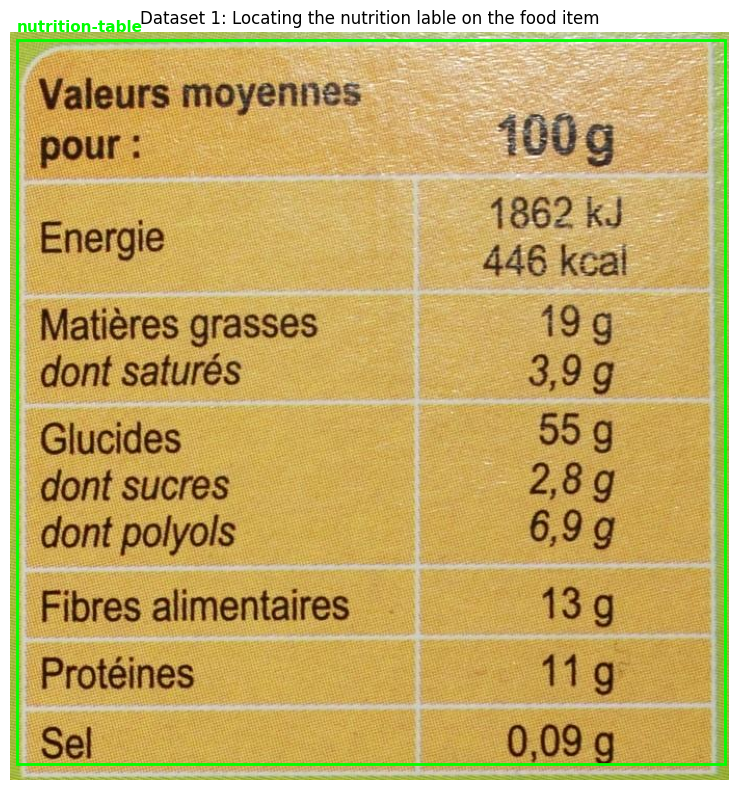

In [ ]:
# Results of the inspection:
# 'bbox'          : normalised coordinates 0.0–1.0  (NOT pixels, or 0–1000)
# 'category_id'   : [0] = nutrition-table
# 'category_name' : ['nutrition-table']

import matplotlib.pyplot as plt
import matplotlib.patches as patches

sample  = table_detection_ds["train"][2]
img     = sample["image"]
objects = sample["objects"]

# image dimensions in pixels
W, H = img.size

print(f"Image size     : {img.size}")
print(f"Boxes found    : {len(objects['bbox'])}")
print(f"Category names : {objects['category_name']}")

# they are 0.0–1.0 normalised
print(f"Raw bbox       : {objects['bbox']}")

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(img)

for bbox, cat_name in zip(objects["bbox"], objects["category_name"]):

    # the format of bbox is: [x_min, y_min, x_max, y_max] normalised 0.0–1.0
    # Converting to actual pixel coordinates for matplotlib
    x1 = bbox[0] * W
    y1 = bbox[1] * H
    x2 = bbox[2] * W
    y2 = bbox[3] * H
    box_w = x2 - x1
    box_h = y2 - y1

    color = "lime" if cat_name == "nutrition-table" else "red"

    rect = patches.Rectangle(
        (x1, y1), box_w, box_h,
        linewidth=2, edgecolor=color, facecolor='none'
    )
    ax.add_patch(rect)
    ax.text(x1, y1 - 8, cat_name, color=color, fontsize=11, fontweight='bold')

ax.set_title("Dataset 1: Locating the nutrition lable on the food item")
ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
#2.Nutrient layout sample exploration

sample   = nutrient_layout_ds["train"][1]

image    = sample["image"]
tokens   = sample["tokens"]
bboxes   = sample["bboxes"]
ner_tags = sample["ner_tags"]

#Extracting label names:
from datasets import Sequence, ClassLabel

feat = nutrient_layout_ds["train"].features["ner_tags"]
if hasattr(feat, "feature"):
    label_names = feat.feature.names
elif hasattr(feat, "names"):
    label_names = feat.names

print(f"Image size  : {image.size}")
print(f"Token count : {len(tokens)}")
print(f"Num labels  : {len(label_names)}")
print()

print(f"{'Token':<15} {'Label'}")
print("-" * 45)
for token, tag_id in zip(tokens, ner_tags):
    label = label_names[tag_id]
    if label != "O":
        print(f"{token:<15} {label}")

Image size  : (3043, 3606)
Token count : 99
Num labels  : 71

Token           Label
---------------------------------------------
(55             B-SERVING_SIZE
g)              I-SERVING_SIZE
60
             B-ENERGY_KCAL_SERVING
3               B-FAT_SERVING
g               I-FAT_SERVING
2               B-SATURATED_FAT_SERVING
g               I-SATURATED_FAT_SERVING
0.1             B-TRANS_FAT_SERVING
g
              I-TRANS_FAT_SERVING
3               B-CARBOHYDRATES_SERVING
g               I-CARBOHYDRATES_SERVING
0g              B-FIBER_SERVING
3               B-SUGARS_SERVING
g
              I-SUGARS_SERVING
6               B-PROTEINS_SERVING
g
              I-PROTEINS_SERVING
15              B-CHOLESTEROL_SERVING
mg
             I-CHOLESTEROL_SERVING
60              B-SODIUM_SERVING
mg
             I-SODIUM_SERVING


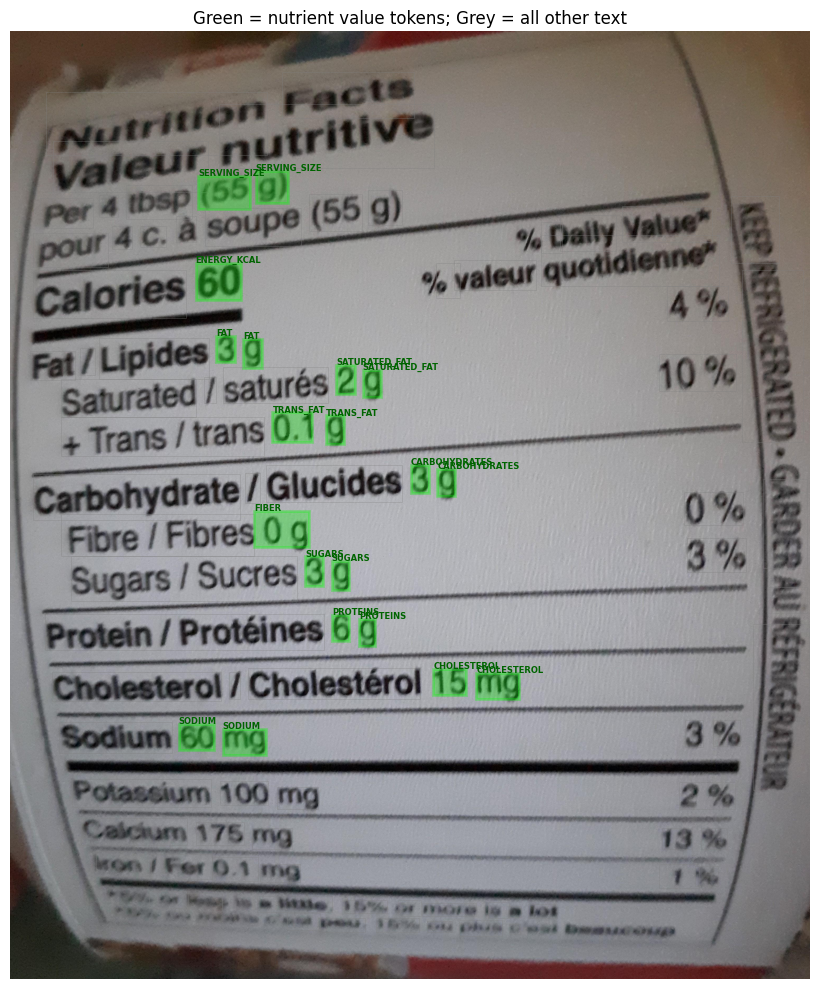

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(image)

W, H = image.size

for token, bbox, tag_id in zip(tokens, bboxes, ner_tags):
    label = label_names[tag_id]

    # The bboxes in this dataset are normalised 0–1000
    # Converting back to pixel coordinates for box
    x1 = bbox[0] / 1000 * W
    y1 = bbox[1] / 1000 * H
    x2 = bbox[2] / 1000 * W
    y2 = bbox[3] / 1000 * H

    if label == "O":
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=0.5, edgecolor="grey", facecolor="none", alpha=0.4
        )
        ax.add_patch(rect)

    else:
        # Nutrient value token - highlighting with green and labelling them
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor="lime", facecolor="lime", alpha=0.3
        )
        ax.add_patch(rect)

        # Strip B-/I- prefix and _SERVING/_100G suffix for label
        short = label.replace("B-", "").replace("I-", "")
        short = short.replace("_SERVING", "").replace("_100G", "")
        ax.text(x1, y1 - 3, short, fontsize=6, color="darkgreen", fontweight="bold")

ax.set_title("Green = nutrient value tokens; Grey = all other text")
ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
from transformers import LayoutLMv3Processor

processor = LayoutLMv3Processor.from_pretrained(
    "microsoft/layoutlmv3-base",
    apply_ocr=False
)

print("Processor loaded")
print(f"Vocab size: {processor.tokenizer.vocab_size}")

preprocessor_config.json:   0%|          | 0.00/275 [00:00<?, ?B/s]

The image processor of type `LayoutLMv3ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/856 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Processor loaded
Vocab size: 50265


Encoder function:

This converts one raw dataset sample into model-ready tensors. It is called on every sample during training/inference.

Takes a raw dataset sample and returns model based input.
The word_labels are used instead of ner_tags directly as,
LayoutLMv3 uses a subword tokeniser (like BERT).

"saturated" might become ["sat" "##urated"] - 2 subword tokens. There is a label for each subword token, but only the FIRST subword of each word gets the real label.
The rest get -100 (ignored in loss).The processor handles this alignment automatically via word_labels.


In [ ]:
# Encoding function:
def encode_sample(sample):
    encoding = processor(
        images=sample["image"],
        text=sample["tokens"],
        boxes=sample["bboxes"],
        word_labels=sample["ner_tags"],
        truncation=True,
        padding="max_length",
        max_length=512,
        return_tensors="pt"
    )
    return {k: v.squeeze(0) for k, v in encoding.items()}


# Testing on a sample:
encoded = encode_sample(nutrient_layout_ds["train"][0])
print("Keys in encoded sample:")
for k, v in encoded.items():
    print(f"  {k:25s}: shape {v.shape}")

Keys in encoded sample:
  input_ids                : shape torch.Size([512])
  attention_mask           : shape torch.Size([512])
  bbox                     : shape torch.Size([512, 4])
  labels                   : shape torch.Size([512])
  pixel_values             : shape torch.Size([3, 224, 224])


In [ ]:
#Applying encoding to the full dataset
# the remove_columns drops the original raw columns that are no longer needed.

print("Encoding training set")
train_encoded = nutrient_layout_ds["train"].map(
    encode_sample,
    remove_columns=nutrient_layout_ds["train"].column_names,
    desc="Encoding train"
)

print("Encoding test set.")
test_encoded = nutrient_layout_ds["test"].map(
    encode_sample,
    remove_columns=nutrient_layout_ds["test"].column_names,
    desc="Encoding test"
)

train_encoded.set_format("torch")
test_encoded.set_format("torch")

print(f"Train : {len(train_encoded)} samples")
print(f"Test  : {len(test_encoded)} samples")

Encoding training set


Encoding train:   0%|          | 0/2884 [00:00<?, ? examples/s]

Encoding test set.


Encoding test:   0%|          | 0/199 [00:00<?, ? examples/s]

Train : 2884 samples
Test  : 199 samples


5

In [ ]:
from transformers import LayoutLMv3ForTokenClassification

num_labels = len(label_names)

model = LayoutLMv3ForTokenClassification.from_pretrained(
    "microsoft/layoutlmv3-base",
    num_labels=num_labels,
    id2label={i: l for i, l in enumerate(label_names)},
    label2id={l: i for i, l in enumerate(label_names)},
)

# Counting the trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: LayoutLMv3-base")
print(f"Trainable parameters: {total_params:,}")
print(f"Output classes: {num_labels}")

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

LayoutLMv3ForTokenClassification LOAD REPORT from: microsoft/layoutlmv3-base
Key                                | Status     | 
-----------------------------------+------------+-
layoutlmv3.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.bias           | MISSING    | 
classifier.out_proj.weight         | MISSING    | 
classifier.dense.weight            | MISSING    | 
classifier.dense.bias              | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: LayoutLMv3-base
Trainable parameters: 125,972,167
Output classes: 71


seqeval is the standard library for evaluating NER/token classification. It understands BIO tagging — a span is only "correct" if BOTH the B- and all I- tokens are predicted correctly. Stricter than token-level accuracy.

In [ ]:
import numpy as np
from seqeval.metrics import classification_report, f1_score


def compute_metrics(eval_pred):
    """ Called after each validation epoch to report precision/recall/F1.
    eval_pred is a tuple of (raw_logits, true_labels).
    """
    logits, labels = eval_pred

    # logits shape: (batch, seq_len, num_labels), take argmax for prediction
    predictions = np.argmax(logits, axis=2)

    # Converting the integer IDs back to string label names, and skipping positions where label == -100 (padding / subword continuations)
    true_labels_list = [
        [label_names[l] for l in label_row if l != -100]
        for label_row in labels
    ]
    pred_labels_list = [
        [label_names[p] for p, l in zip(pred_row, label_row) if l != -100]
        for pred_row, label_row in zip(predictions, labels)
    ]

    return {
        "f1"       : f1_score(true_labels_list, pred_labels_list),
        "report"   : classification_report(true_labels_list, pred_labels_list)
    }

In [ ]:
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

training_args = TrainingArguments(
    output_dir="./layoutlmv3-nutrient-extraction-v2",

    num_train_epochs=12,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=4,

    learning_rate=1e-5,
    warmup_ratio=0.0,

    eval_strategy="steps",
    eval_steps=500,
    save_steps=500,
    logging_steps=100,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,

    fp16=True,
    dataloader_num_workers=4,
    dataloader_pin_memory=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_encoded,
    eval_dataset=test_encoded,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=4)]
)

print("Starting training — fixed learning rate 1e-5")
trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting training — fixed learning rate 1e-5


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Step,Training Loss,Validation Loss,F1,Report
500,1.524185,0.312880,0.543055,precision recall f1-score support ADDED_SUGARS_SERVING 0.00 0.00 0.00 3 CALCIUM_100G 0.00 0.00 0.00 5 CALCIUM_SERVING 0.00 0.00 0.00 3 CARBOHYDRATES_100G 0.48 0.61 0.53 178 CARBOHYDRATES_SERVING 0.27 0.58 0.36 66 CHOLESTEROL_SERVING 0.00 0.00 0.00 6 ENERGY_KCAL_100G 0.81 0.91 0.86 173 ENERGY_KCAL_SERVING 0.60 0.78 0.68 64 ENERGY_KJ_100G 0.74 0.93 0.82 182 ENERGY_KJ_SERVING 0.33 0.23 0.27 57 FAT_100G 0.63 0.86 0.73 182 FAT_SERVING 0.31 0.26 0.28 65 FIBER_100G 1.00 0.01 0.02 85 FIBER_SERVING 0.00 0.00 0.00 51 IRON_SERVING 0.00 0.00 0.00 1 POTASSIUM_SERVING 0.00 0.00 0.00 4 PROTEINS_100G 0.43 0.73 0.54 175 PROTEINS_SERVING 0.21 0.40 0.27 63 SALT_100G 0.50 0.91 0.65 173 SALT_SERVING 0.13 0.14 0.14 50 SATURATED_FAT_100G 0.43 0.51 0.47 177 SATURATED_FAT_SERVING 0.29 0.18 0.22 61 SERVING_SIZE 0.71 0.69 0.70 67 SODIUM_100G 0.00 0.00 0.00 3 SODIUM_SERVING 0.00 0.00 0.00 13 SUGARS_100G 0.44 0.65 0.53 173 SUGARS_SERVING 0.17 0.13 0.15 63 TRANS_FAT_100G 0.00 0.00 0.00 1 TRANS_FAT_SERVING 0.00 0.00 0.00 6 VITAMIN_D_100G 0.00 0.00 0.00 2 VITAMIN_D_SERVING 0.00 0.00 0.00 1 micro avg 0.49 0.60 0.54 2153 macro avg 0.27 0.31 0.27 2153 weighted avg 0.49 0.60 0.51 2153
1000,0.988119,0.222523,0.705882,precision recall f1-score support ADDED_SUGARS_SERVING 0.00 0.00 0.00 3 CALCIUM_100G 0.00 0.00 0.00 5 CALCIUM_SERVING 0.00 0.00 0.00 3 CARBOHYDRATES_100G 0.65 0.71 0.68 178 CARBOHYDRATES_SERVING 0.31 0.65 0.42 66 CHOLESTEROL_SERVING 0.00 0.00 0.00 6 ENERGY_KCAL_100G 0.92 0.95 0.93 173 ENERGY_KCAL_SERVING 0.72 0.91 0.81 64 ENERGY_KJ_100G 0.91 0.93 0.92 182 ENERGY_KJ_SERVING 0.85 0.88 0.86 57 FAT_100G 0.82 0.87 0.85 182 FAT_SERVING 0.73 0.83 0.78 65 FIBER_100G 0.24 0.18 0.20 85 FIBER_SERVING 0.00 0.00 0.00 51 IRON_SERVING 0.00 0.00 0.00 1 POTASSIUM_SERVING 0.00 0.00 0.00 4 PROTEINS_100G 0.66 0.86 0.74 175 PROTEINS_SERVING 0.52 0.84 0.64 63 SALT_100G 0.81 0.89 0.85 173 SALT_SERVING 0.56 0.80 0.66 50 SATURATED_FAT_100G 0.73 0.79 0.76 177 SATURATED_FAT_SERVING 0.29 0.34 0.32 61 SERVING_SIZE 0.78 0.81 0.79 67 SODIUM_100G 0.00 0.00 0.00 3 SODIUM_SERVING 0.40 0.15 0.22 13 SUGARS_100G 0.60 0.75 0.67 173 SUGARS_SERVING 0.30 0.51 0.38 63 TRANS_FAT_100G 0.00 0.00 0.00 1 TRANS_FAT_SERVING 0.00 0.00 0.00 6 VITAMIN_D_100G 0.00 0.00 0.00 2 VITAMIN_D_SERVING 0.00 0.00 0.00 1 micro avg 0.67 0.75 0.71 2153 macro avg 0.38 0.44 0.40 2153 weighted avg 0.66 0.75 0.70 2153


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['layoutlmv3.embeddings.LayerNorm.weight', 'layoutlmv3.embeddings.LayerNorm.bias', 'layoutlmv3.LayerNorm.weight', 'layoutlmv3.LayerNorm.bias', 'layoutlmv3.encoder.layer.0.attention.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.0.attention.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.0.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.0.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.1.attention.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.1.attention.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.1.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.1.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.2.attention.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.2.attention.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.2.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.2.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.3.attention.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.3.attention.out

TrainOutput(global_step=1092, training_loss=1.906018037062425, metrics={'train_runtime': 4089.048, 'train_samples_per_second': 8.464, 'train_steps_per_second': 0.267, 'total_flos': 9190875402584064.0, 'train_loss': 1.906018037062425, 'epoch': 12.0})

In [ ]:
# Running on the test set
#printing the calssification report results
results = trainer.evaluate()

print(f"\nOverall F1   : {results['eval_f1']:.4f}")
print(f"Overall Loss : {results['eval_loss']:.4f}")
print()

print("Per-nutrient breakdown:")
print(results.get("eval_report", "Run compute_metrics manually for full report"))


Overall F1   : 0.7059
Overall Loss : 0.2225

Per-nutrient breakdown:
                       precision    recall  f1-score   support

 ADDED_SUGARS_SERVING       0.00      0.00      0.00         3
         CALCIUM_100G       0.00      0.00      0.00         5
      CALCIUM_SERVING       0.00      0.00      0.00         3
   CARBOHYDRATES_100G       0.65      0.71      0.68       178
CARBOHYDRATES_SERVING       0.31      0.65      0.42        66
  CHOLESTEROL_SERVING       0.00      0.00      0.00         6
     ENERGY_KCAL_100G       0.92      0.95      0.93       173
  ENERGY_KCAL_SERVING       0.72      0.91      0.81        64
       ENERGY_KJ_100G       0.91      0.93      0.92       182
    ENERGY_KJ_SERVING       0.85      0.88      0.86        57
             FAT_100G       0.82      0.87      0.85       182
          FAT_SERVING       0.73      0.83      0.78        65
           FIBER_100G       0.24      0.18      0.20        85
        FIBER_SERVING       0.00      0.00     

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/smart-label-analytics', exist_ok=True)

model.save_pretrained('/content/drive/MyDrive/smart-label-analytics/final-model')
processor.save_pretrained('/content/drive/MyDrive/smart-label-analytics/processor')

print("Saved to Drive")

Mounted at /content/drive


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to Drive


In [ ]:
!apt-get install -y tesseract-ocr -q
!pip install -q pytesseract

Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


"""
    Full inference pipeline:
      1. Load image
      2. Run OCR (using pytesseract — needed for real new images)
      3. Encode image + tokens + bboxes for LayoutLMv3
      4. Run model inference
      5. Decode predictions → structured nutrient dict
    """

In [ ]:
# The function takes any food packaging image as input and get back structured nutritional data.

import re
from PIL import Image

def extract_nutrients(image_path: str, model, processor, label_names: list) -> dict:
    import pytesseract

    # 1.Loading the image image
    image = Image.open(image_path).convert("RGB")
    W, H  = image.size

    # 2. OCR : getting the tokens and their pixel positions
    # the 'pytesseract' returns a dataframe with word + bounding box per row
    ocr_data = pytesseract.image_to_data(
        image, output_type=pytesseract.Output.DICT
    )

    tokens, boxes = [], []
    for i, word in enumerate(ocr_data["text"]):
        word = word.strip()
        if not word:
            continue

        x, y = ocr_data["left"][i], ocr_data["top"][i]
        w, h = ocr_data["width"][i], ocr_data["height"][i]
        x1 = int(x / W * 1000)
        y1 = int(y / H * 1000)
        x2 = int((x + w) / W * 1000)
        y2 = int((y + h) / H * 1000)
        tokens.append(word)
        boxes.append([x1, y1, x2, y2])

    if not tokens:
        return {"error": "No text found in image"}

    # 3. Encode for model
    encoding = processor(
        images=image,
        text=tokens,
        boxes=boxes,
        truncation=True,
        padding="max_length",
        max_length=512,
        return_tensors="pt"
    ).to(model.device)

    # 4. Inference
    import torch
    model.eval()
    with torch.no_grad():
        outputs = model(**encoding)

    # 5. Decoding the predictions
    predictions = outputs.logits.argmax(dim=-1).squeeze().tolist()
    input_ids   = encoding["input_ids"].squeeze().tolist()

    #6. Reconstructing which token got which label

    word_predictions = {}
    tokens_decoded   = processor.tokenizer.convert_ids_to_tokens(input_ids)

    current_value  = []
    current_label  = None

    for token_str, pred_id in zip(tokens_decoded, predictions):
        if token_str in ["<s>", "</s>", "<pad>"]:
            continue

        label = label_names[pred_id]

        if label.startswith("B-"):

            if current_label and current_value:
                clean = " ".join(current_value).strip()
                word_predictions[current_label] = clean

            current_label = label[2:]
            current_value = [token_str.replace("▁","").replace("Ġ","")]

        elif label.startswith("I-") and current_label:
            current_value.append(token_str.replace("▁","").replace("Ġ",""))

        else:
            if current_label and current_value:
                clean = " ".join(current_value).strip()
                word_predictions[current_label] = clean
            current_label = None
            current_value = []

    return word_predictions


#Testing on a sample from the test set

test_sample = nutrient_layout_ds["test"][5]
test_sample["image"].save("/tmp/test_package.jpg")

nutrients = extract_nutrients("/tmp/test_package.jpg", model, processor, label_names)

print("Extracted nutrients:")
print("-" * 40)
for nutrient, value in sorted(nutrients.items()):
    print(f"  {nutrient:<35} : {value}")

Extracted nutrients:
----------------------------------------
  ENERGY_KCAL_100G                    : 365 kcal
  ENERGY_KJ_100G                      : 46 k J
  FAT_100G                            : 69
  SATURATED_FAT_100G                  : 08 g


In [ ]:
test_sample = nutrient_layout_ds["test"][5]

encoding = processor(
    images=test_sample["image"],
    text=test_sample["tokens"],
    boxes=test_sample["bboxes"],
    truncation=True,
    padding="max_length",
    max_length=512,
    return_tensors="pt"
)
encoding = {k: v.to(model.device) for k, v in encoding.items()}

model.eval()
import torch
with torch.no_grad():
    outputs = model(**encoding)

predictions    = outputs.logits.argmax(dim=-1).squeeze().tolist()
tokens_decoded = processor.tokenizer.convert_ids_to_tokens(
    encoding["input_ids"].squeeze().tolist()
)

nutrients_clean = {}
current_label   = None
current_value   = []

for token_str, pred_id in zip(tokens_decoded, predictions):
    if token_str in ["<s>", "</s>", "<pad>"]:
        continue
    label     = label_names[pred_id]
    clean_tok = token_str.replace("\u2581","").replace("\u0120","").strip()
    if not clean_tok:
        continue
    if label == "O":
        if current_label and current_value:
            nutrients_clean[current_label] = "".join(current_value)
        current_label = None
        current_value = []
    elif label.startswith("B-"):
        nutrient = label[2:]
        if nutrient == current_label:
            current_value.append(clean_tok)
        else:
            if current_label and current_value:
                nutrients_clean[current_label] = "".join(current_value)
            current_label = nutrient
            current_value = [clean_tok]
    elif label.startswith("I-") and current_label:
        current_value.append(clean_tok)

if current_label and current_value:
    nutrients_clean[current_label] = "".join(current_value)

nutrients_clean = {
    k: v.replace("\u010a", "").strip()
    for k, v in nutrients_clean.items()
}

print("Extracted nutrients:")
print("-" * 45)
for k, v in sorted(nutrients_clean.items()):
    print(f"  {k:<35} : {v}")

Extracted nutrients:
---------------------------------------------
  CARBOHYDRATES_100G                  : 73g
  ENERGY_KCAL_100G                    : 365kcal
  ENERGY_KJ_100G                      : 1546kJ
  FAT_100G                            : 3,6g
  FIBER_100G                          : 3,4g
  PROTEINS_100G                       : 8,5g
  SALT_100G                           : <0,01g
  SATURATED_FAT_100G                  : 0,8g
  SUGARS_100G                         : 1,1g


In [ ]:
import re

def parse_value(value_str: str) -> float:
    """Extract the first number from a string like '14 g' or '94kJ'."""
    match = re.search(r"[\d.,]+", value_str.replace(",", "."))
    return float(match.group()) if match else 0.0


def score_product(nutrients: dict) -> dict:

    #Input : dict of {NUTRIENT_NAME: value_string} from extract_nutrients()
    #Output: health score (0-100), grade (A-E), advice string

    score = 50  # start neutral

    def get(key):
        for suffix in ["_100G", "_SERVING"]:
            val = nutrients.get(key + suffix)
            if val:
                return parse_value(val)
        return None

    energy  = get("ENERGY_KCAL")
    sat_fat = get("SATURATED_FAT")
    sugars  = get("SUGARS")
    salt    = get("SALT")
    fibre   = get("FIBER")
    protein = get("PROTEINS")

    breakdown = {}

    if energy:
        penalty = min((energy - 200) / 200 * 10, 10) if energy > 200 else 0
        score -= penalty
        breakdown["energy"] = f"{energy:.0f} kcal  (penalty: -{penalty:.1f})"

    if sat_fat:
        penalty = min(sat_fat / 5 * 8, 15)
        score -= penalty
        breakdown["saturated_fat"] = f"{sat_fat:.1f}g  (penalty: -{penalty:.1f})"

    if sugars:
        penalty = min(sugars / 12.5 * 8, 15)
        score -= penalty
        breakdown["sugars"] = f"{sugars:.1f}g  (penalty: -{penalty:.1f})"

    if salt:
        penalty = min(salt / 1.5 * 8, 10)
        score -= penalty
        breakdown["salt"] = f"{salt:.1f}g  (penalty: -{penalty:.1f})"

    if fibre:
        bonus = min(fibre / 3 * 8, 10)
        score += bonus
        breakdown["fibre"] = f"{fibre:.1f}g  (bonus: +{bonus:.1f})"

    if protein:
        bonus = min(protein / 10 * 6, 8)
        score += bonus
        breakdown["protein"] = f"{protein:.1f}g  (bonus: +{bonus:.1f})"

    score = max(0, min(100, round(score)))

    if score >= 75:
        grade, advice = "A", "Excellent nutritional profile."
    elif score >= 60:
        grade, advice = "B", "Good choice. Balanced nutritional profile."
    elif score >= 45:
        grade, advice = "C", "Moderate. Fine occasionally, watch portions."
    elif score >= 30:
        grade, advice = "D", "High in fat/sugar/salt. Limit frequency."
    else:
        grade, advice = "E", "Poor nutritional profile. Consider alternatives."

    return {
        "score"     : score,
        "grade"     : grade,
        "advice"    : advice,
        "breakdown" : breakdown,
    }


def print_report(nutrients: dict):
    result = score_product(nutrients)
    bar    = "█" * (result["score"] // 5) + "░" * (20 - result["score"] // 5)

    print("=" * 50)
    print("  SMART LABEL ANALYSIS")
    print("=" * 50)
    print(f"  Health Score : {result['score']}/100")
    print(f"  [{bar}]")
    print(f"  Grade        : {result['grade']}")
    print(f"  Advice       : {result['advice']}")
    print()
    print("  Nutrient breakdown (per 100g):")
    print("-" * 50)
    for nutrient, detail in result["breakdown"].items():
        print(f"    {nutrient:<20} : {detail}")
    print("=" * 50)



print_report(nutrients_clean)

  SMART LABEL ANALYSIS
  Health Score : 54/100
  [██████████░░░░░░░░░░]
  Grade        : C
  Advice       : Moderate. Fine occasionally, watch portions.

  Nutrient breakdown (per 100g):
--------------------------------------------------
    energy               : 365 kcal  (penalty: -8.2)
    saturated_fat        : 0.8g  (penalty: -1.3)
    sugars               : 1.1g  (penalty: -0.7)
    salt                 : 0.0g  (penalty: -0.1)
    fibre                : 3.4g  (bonus: +9.1)
    protein              : 8.5g  (bonus: +5.1)


In [ ]:
meta = nutrient_layout_ds["test"][5]["meta"]
print("Barcode   :", meta["barcode"])
print("Image URL :", meta["image_url"])
print("USDA table:", meta["usda_table"])


Barcode   : 4018722344353
Image URL : https://images.openfoodfacts.org/images/products/401/872/234/4353/2.jpg
USDA table: False


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/smart-label-analytics', exist_ok=True)

model.save_pretrained('/content/drive/MyDrive/smart-label-analytics/final-model')
processor.save_pretrained('/content/drive/MyDrive/smart-label-analytics/processor')

import json
with open('/content/drive/MyDrive/smart-label-analytics/label_names.json', 'w') as f:
    json.dump(label_names, f)

print("Saved to Drive:")
print("  final-model/")
print("  processor/")
print("  label_names.json")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to Drive:
  final-model/
  processor/
  label_names.json
